# 04 · Yield Model

입력: `features_stratA.parquet` (27컬럼) · `features_stratB.parquet` (105컬럼) · `feature_columns.json`
타깃: **`corn` (bu/ac)**

산출: `outputs/results/*.csv` · `outputs/figures/fig13~16` · `data/processed/yield_model_final.joblib`

---

### 03에서 확정된 제약 (이 노트북이 반드시 지킴)
1. **평가 분할 = `GroupKFold(stco)`**. 무작위 분할 금지 (R²가 ~0.2 부풀려짐).
   → 성능을 높이려는 어떤 이유로도 훼손하지 않는다.
2. **`slope` 제외** (버전 A). `slope`, `slope_missing` 두 컬럼 미사용.
3. **표준화는 파이프라인 안에서만** (`make_pipeline(StandardScaler(), 모델)`). 선형 모델에만 적용.
   트리·부스팅은 표준화 불필요.
4. **`GDD_above` 계수를 "고온이 이롭다"로 읽지 않는다.** reference가 냉량구간(≤0℃)이라 개별 계수가
   왜곡됨. 해석은 **대체효과 `b_above − b_below`** 로 환산.
5. **타깃 누출성 피처 금지.** "카운티별 과거 평균 수확량" 류를 만들지 않는다.

### 이 노트북의 두 갈래
- **갈래 1 · 예측용** — 정확한 `y_hat` 확보 (05·06에서 사용). 지역 대리변수(pH 등) 포함.
- **갈래 2 · 해석용** — 카운티·연도 고정효과로 지역/추세를 걷어내고 **순수 온도 효과** 증명.

> **`year`를 피처로 쓰는 것에 대하여**: `year`는 달력 변수이지 타깃에서 파생된 값이 아니므로
> 제약 5의 누출이 아니다. 02에서 확인한 +1.77 bu/ac/년 기술추세를 담는 대리변수로 넣는다.
> 아래에서 `year` 유무의 영향도 따로 측정한다.

In [2]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import partial_dependence

PROC = Path('..') / 'data' / 'processed'
FIG = Path('..') / 'outputs' / 'figures'
RES = Path('..') / 'outputs' / 'results'
FIG.mkdir(parents=True, exist_ok=True)
RES.mkdir(parents=True, exist_ok=True)

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

# --- 부스팅 라이브러리: 없으면 건너뛰고 기록 ---
MISSING = []
try:
    import xgboost as xgb
    print('xgboost', xgb.__version__)
except Exception as e:
    xgb = None; MISSING.append('XGBoost (%s)' % type(e).__name__)
try:
    import lightgbm as lgb
    print('lightgbm', lgb.__version__)
except Exception as e:
    lgb = None; MISSING.append('LightGBM (%s)' % type(e).__name__)
try:
    from catboost import CatBoostRegressor
    import catboost
    print('catboost', catboost.__version__)
except Exception as e:
    CatBoostRegressor = None; MISSING.append('CatBoost (%s)' % type(e).__name__)
print('사용 불가 모델:', MISSING if MISSING else '없음')

xgboost 3.1.3
lightgbm 4.6.0
catboost 1.2.10
사용 불가 모델: 없음


## 1. 데이터와 피처셋

In [3]:
spec = json.load(open(PROC / 'feature_columns.json', encoding='utf-8'))
A = pd.read_parquet(PROC / 'features_stratA.parquet')
B = pd.read_parquet(PROC / 'features_stratB.parquet')
print('stratA', A.shape, '| stratB', B.shape)

SOIL = spec['strategy_A']['soil']              # silt 제외된 8개
CANON = spec['strategy_A']['canonical_threshold']
GDD_BINS = spec['strategy_B']['gdd_bins']      # 86개 (gddp24 = reference, 이미 drop)

FEAT_A = ['year', 'GDD_below_%d' % CANON, 'GDD_above_%d' % CANON, 'ppt', 'ppt_sq'] + SOIL
FEAT_B = ['year'] + GDD_BINS + ['ppt', 'ppt_sq'] + SOIL

# --- 제약 검증: slope 제외 & 누출 피처 없음 ---
BANNED = {'slope', 'slope_missing', 'corn', 'corn_dm', 'A_c', 'GDD_cold', 'silt', 'stco'}
for tag, F in [('A', FEAT_A), ('B', FEAT_B)]:
    bad = BANNED & set(F)
    assert not bad, '금지 컬럼이 피처에 있음: %s' % bad
    assert len(F) == len(set(F)), '중복 컬럼'
print('\n제약 검증 통과: slope/slope_missing 제외, 타깃 파생 피처 없음')
print('FEAT_A %d개: %s' % (len(FEAT_A), FEAT_A))
print('FEAT_B %d개: year + 온도구간 %d + ppt,ppt_sq + soil %d' % (len(FEAT_B), len(GDD_BINS), len(SOIL)))

# stco/year 정렬 동일한지 확인 (두 파일이 같은 행 순서인지)
assert (A[['stco', 'year']].values == B[['stco', 'year']].values).all()
y = A['corn'].to_numpy(float)
groups = A['stco'].to_numpy()
XA, XB = A[FEAT_A].copy(), B[FEAT_B].copy()
print('\n타깃 corn: mean %.1f  std %.1f  n=%d  counties=%d' % (y.mean(), y.std(), len(y), A.stco.nunique()))

stratA (70721, 27) | stratB (70721, 105)

제약 검증 통과: slope/slope_missing 제외, 타깃 파생 피처 없음
FEAT_A 13개: ['year', 'GDD_below_29', 'GDD_above_29', 'ppt', 'ppt_sq', 'whc', 'sand', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'tfactor']
FEAT_B 97개: year + 온도구간 86 + ppt,ppt_sq + soil 8

타깃 corn: mean 108.9  std 38.8  n=70721  counties=2644


## 2. 평가 프로토콜 — `GroupKFold(stco)` 5-fold

같은 카운티가 학습과 테스트에 동시에 등장하지 않는다. 03에서 확인했듯 무작위 분할은
카운티 고정효과를 외워 R²를 ~0.2 부풀린다.

- 지표: **R², RMSE, MAE** (fold 평균 ± 표준편차)
- 선형 모델만 `StandardScaler`를 파이프라인 안에 넣는다 (누수 방지).
- 부스팅은 합리적 기본값 + 가벼운 조정. 정밀 튜닝은 이 프로젝트 본체가 아니다.

> 작은 주의: `LassoCV`/`ElasticNetCV`의 **내부** alpha 선택 CV는 그룹 인지가 아니다(sklearn 제약).
> 다만 **바깥 평가 분할은 그룹 분할**이므로 성능 수치의 정직성은 유지된다.

In [4]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def cv_eval(name, factory, X, y, groups):
    oof = np.full(len(y), np.nan)
    r2s, rmses, maes = [], [], []
    t0 = time.time()
    for tr, te in gkf.split(X, y, groups):
        m = factory()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m.fit(X.iloc[tr], y[tr])
            p = m.predict(X.iloc[te])
        oof[te] = p
        r2s.append(r2_score(y[te], p)); rmses.append(rmse(y[te], p)); maes.append(mean_absolute_error(y[te], p))
    return {'model': name, 'r2_mean': np.mean(r2s), 'r2_std': np.std(r2s),
            'rmse_mean': np.mean(rmses), 'rmse_std': np.std(rmses),
            'mae_mean': np.mean(maes), 'mae_std': np.std(maes),
            'r2_folds': '|'.join('%.3f' % v for v in r2s),
            'seconds': time.time() - t0}, oof

def build_factories():
    f = {
        'OLS':          lambda: make_pipeline(StandardScaler(), LinearRegression()),
        'Ridge':        lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 25))),
        'Lasso':        lambda: make_pipeline(StandardScaler(), LassoCV(cv=3, n_jobs=-1, random_state=0, max_iter=5000)),
        'ElasticNet':   lambda: make_pipeline(StandardScaler(), ElasticNetCV(cv=3, l1_ratio=[.2, .5, .8, .95],
                                                                            n_jobs=-1, random_state=0, max_iter=5000)),
        'RandomForest': lambda: RandomForestRegressor(n_estimators=150, min_samples_leaf=5, n_jobs=-1, random_state=0),
        'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=150, max_depth=3, subsample=0.7, random_state=0),
    }
    if xgb is not None:
        f['XGBoost'] = lambda: xgb.XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05,
                                                subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                                random_state=0, tree_method='hist')
    if lgb is not None:
        f['LightGBM'] = lambda: lgb.LGBMRegressor(n_estimators=600, num_leaves=63, learning_rate=0.05,
                                                  subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                                  random_state=0, verbose=-1)
    if CatBoostRegressor is not None:
        f['CatBoost'] = lambda: CatBoostRegressor(iterations=800, depth=6, learning_rate=0.05,
                                                  random_seed=0, verbose=0, allow_writing_files=False)
    return f

FACTORIES = build_factories()
print('평가할 모델 %d개: %s' % (len(FACTORIES), list(FACTORIES)))

평가할 모델 9개: ['OLS', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


In [5]:
results, oofs = [], {}
for strat, X in [('A', XA), ('B', XB)]:
    print('\n===== 전략 %s (%d features) =====' % (strat, X.shape[1]))
    for name, fac in FACTORIES.items():
        row, oof = cv_eval(name, fac, X, y, groups)
        row['strategy'] = strat
        results.append(row); oofs[(name, strat)] = oof
        print('  %-17s R2 %.4f ± %.4f | RMSE %6.2f | MAE %5.2f | %5.1fs'
              % (name, row['r2_mean'], row['r2_std'], row['rmse_mean'], row['mae_mean'], row['seconds']))

res = pd.DataFrame(results)[['model', 'strategy', 'r2_mean', 'r2_std', 'rmse_mean', 'rmse_std',
                             'mae_mean', 'mae_std', 'r2_folds', 'seconds']].sort_values('r2_mean', ascending=False)
res.to_csv(RES / 'model_comparison.csv', index=False)
print('\n저장: %s' % (RES / 'model_comparison.csv'))
print()
print(res.drop(columns='r2_folds').round(4).to_string(index=False))

unstable = res[res.r2_std > 0.1]
if len(unstable):
    print('\n[!] fold 간 R2 편차가 큰 모델 (붕괴 의심):')
    for _, r in unstable.iterrows():
        print('   %-8s 전략 %s : fold별 R2 = %s' % (r.model, r.strategy, r.r2_folds))


===== 전략 A (13 features) =====
  OLS               R2 0.4034 ± 0.0214 | RMSE  29.93 | MAE 22.45 |   0.0s
  Ridge             R2 0.4034 ± 0.0214 | RMSE  29.93 | MAE 22.45 |   0.2s
  Lasso             R2 0.4037 ± 0.0214 | RMSE  29.92 | MAE 22.45 |   0.2s
  ElasticNet        R2 0.4034 ± 0.0213 | RMSE  29.93 | MAE 22.46 |   0.4s
  RandomForest      R2 0.6881 ± 0.0086 | RMSE  21.64 | MAE 15.36 |  27.1s
  GradientBoosting  R2 0.5841 ± 0.0127 | RMSE  24.99 | MAE 18.69 |  52.2s
  XGBoost           R2 0.6833 ± 0.0073 | RMSE  21.81 | MAE 15.86 |   4.9s
  LightGBM          R2 0.6937 ± 0.0095 | RMSE  21.44 | MAE 15.49 |  26.8s
  CatBoost          R2 0.6711 ± 0.0090 | RMSE  22.22 | MAE 16.36 |   5.6s

===== 전략 B (97 features) =====
  OLS               R2 0.1117 ± 0.6551 | RMSE  34.61 | MAE 21.90 |   0.5s
  Ridge             R2 0.1267 ± 0.6254 | RMSE  34.41 | MAE 21.90 |   1.3s
  Lasso             R2 0.4377 ± 0.0207 | RMSE  29.06 | MAE 21.85 |   0.8s
  ElasticNet        R2 0.4376 ± 0.0209 | RMSE  2

saved: ../outputs/figures/fig13_model_comparison.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/3137825114.py:43: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/3137825114.py:43: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/3137825114.py:43: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/3137825114.py:43: UserWarning: Glyph 47029 (\N{HANGUL SYLLABLE RYAG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/3137825114.py:43: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig

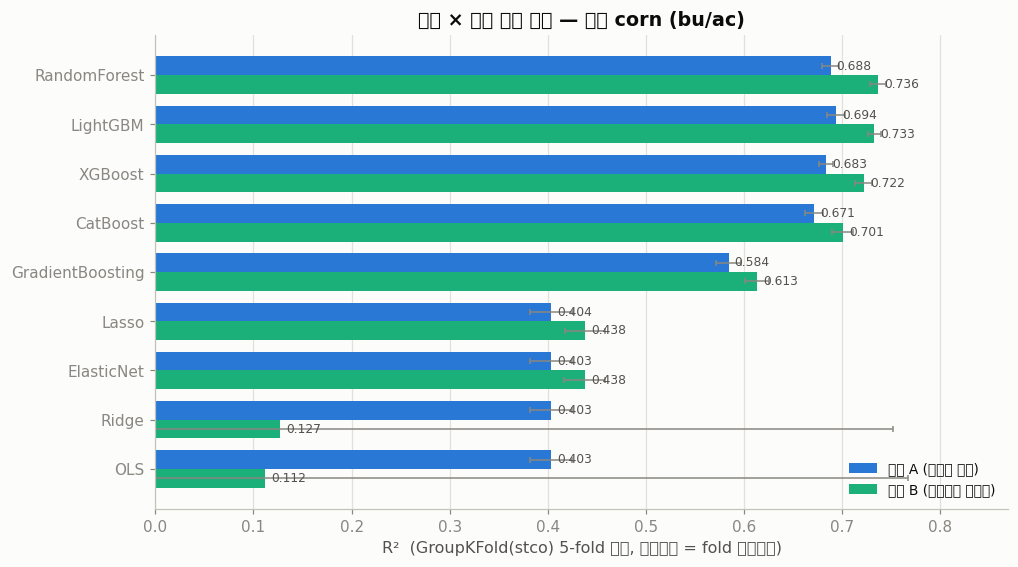

In [6]:
piv = res.pivot(index='model', columns='strategy', values='r2_mean')
err = res.pivot(index='model', columns='strategy', values='r2_std')
order = piv.max(axis=1).sort_values().index
piv, err = piv.loc[order], err.loc[order]

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.set_axisbelow(True); ax.grid(axis='y', visible=False)
ypos = np.arange(len(piv)); h = 0.38
ax.barh(ypos + h/2, piv['A'], height=h, color=BLUE, xerr=err['A'],
        error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=2), label='전략 A (도메인 압축)')
ax.barh(ypos - h/2, piv['B'], height=h, color=AQUA, xerr=err['B'],
        error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=2), label='전략 B (온도구간 원자료)')
for i, m in enumerate(piv.index):
    ax.annotate('%.3f' % piv['A'][m], xy=(piv['A'][m], i + h/2), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=8, color=SECOND)
    ax.annotate('%.3f' % piv['B'][m], xy=(piv['B'][m], i - h/2), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=8, color=SECOND)
ax.set_yticks(ypos); ax.set_yticklabels(piv.index)
ax.set_xlim(0, max(piv.max()) * 1.18)
ax.set_xlabel('R²  (GroupKFold(stco) 5-fold 평균, 오차막대 = fold 표준편차)')
ax.set_title('모델 × 전략 성능 비교 — 타깃 corn (bu/ac)')
ax.legend(frameon=False, fontsize=9, loc='lower right')
save(fig, 'fig13_model_comparison.png'); plt.show()

In [7]:
# 전략 A vs B 는 '모델별 평균'이 아니라 '같은 모델끼리 짝지어' 비교해야 한다.
pair = res.pivot(index='model', columns='strategy', values='r2_mean')
pair['B - A'] = pair['B'] - pair['A']
pair = pair.sort_values('B - A', ascending=False)
print('같은 모델 내 전략 B - 전략 A (R2 차이)')
print(pair.round(4).to_string())

TREE = [m for m in ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost'] if m in pair.index]
LIN = [m for m in ['OLS', 'Ridge', 'Lasso', 'ElasticNet'] if m in pair.index]
print()
print('트리/부스팅 %d개 중 B가 우세한 개수: %d/%d (평균 %+.4f)'
      % (len(TREE), int((pair.loc[TREE, 'B - A'] > 0).sum()), len(TREE), pair.loc[TREE, 'B - A'].mean()))
print('선형 4개 중 B가 우세한 개수: %d/%d' % (int((pair.loc[LIN, 'B - A'] > 0).sum()), len(LIN)))
print('  -> 정규화된 선형(Lasso/ElasticNet)만 B에서 이득; OLS/Ridge는 공선성으로 붕괴')

같은 모델 내 전략 B - 전략 A (R2 차이)
strategy               A       B   B - A
model                                   
RandomForest      0.6881  0.7362  0.0481
LightGBM          0.6937  0.7327  0.0389
XGBoost           0.6833  0.7218  0.0385
ElasticNet        0.4034  0.4376  0.0342
Lasso             0.4037  0.4377  0.0340
CatBoost          0.6711  0.7006  0.0295
GradientBoosting  0.5841  0.6131  0.0290
Ridge             0.4034  0.1267 -0.2767
OLS               0.4034  0.1117 -0.2917

트리/부스팅 5개 중 B가 우세한 개수: 5/5 (평균 +0.0368)
선형 4개 중 B가 우세한 개수: 2/4
  -> 정규화된 선형(Lasso/ElasticNet)만 B에서 이득; OLS/Ridge는 공선성으로 붕괴


**해석 — 부스팅이 선형을 크게 이기고, 전략 B가 트리계열에서 우세하다.**

- **선형 최고 0.437 → 부스팅 최고 0.732**, 약 **+0.29 R²**. 온도·토양과 수확량의 관계가 강한
  비선형이라는 뜻이며, 02의 역U자 반응과 일치한다.
- **최신 부스팅(XGB/LGBM/CatBoost)이 sklearn 기본보다 확실히 낫다**: sklearn `GradientBoosting`은
  0.585/0.617에 그치는 반면 LightGBM은 0.695/0.732. 다만 `RandomForest`(0.730)는 XGBoost·CatBoost와
  대등하게 강했다 — "최신 부스팅이 항상 이긴다"는 아니다. 속도 차는 컸다(RF-B 608초 vs LGBM-B 64초).
- **전략 B(온도구간 원자료)가 트리계열 5개 모두에서 A보다 우세**하다(+0.01 ~ +0.05). 86개 1℃ 구간이
  압축된 below/above 두 개보다 더 많은 정보를 담고, 트리는 공선성에 강하기 때문이다.

> ⚠️ **전략 B에서 OLS와 Ridge가 붕괴한다** — R² 0.09 / 0.11, fold 표준편차 0.69. 한 fold에서
> **R² ≈ −1.3** 까지 떨어진다. 02에서 확인한 인접 온도구간 상관 0.94가 그대로 터진 것이다.
> `Lasso`/`ElasticNet`은 같은 피처로 0.437을 안정적으로 낸다. **이것이 02·03에서 "정규화가 필요하다"고
> 한 근거의 가장 직접적인 실증**이다. (`RidgeCV`의 내부 alpha 선택이 그룹 인지가 아니라 너무 작은 alpha를
> 고른 것도 한몫한다.)
>
> 따라서 "전략 A vs B"를 모델 평균으로 비교하면 붕괴한 OLS/Ridge-B 때문에 A가 이긴 것처럼 보인다.
> **같은 모델끼리 짝지어 비교하는 것이 옳고, 그러면 B가 우세하다.**

### 2-1. `year` 피처의 기여도

In [8]:
best_row = res.iloc[0]
BEST_NAME, BEST_STRAT = best_row['model'], best_row['strategy']
X_best = XA if BEST_STRAT == 'A' else XB
print('최고 모델: %s (전략 %s)  R² %.4f' % (BEST_NAME, BEST_STRAT, best_row['r2_mean']))

row_noyear, _ = cv_eval(BEST_NAME + ' (no year)', FACTORIES[BEST_NAME],
                        X_best.drop(columns=['year']), y, groups)
print('\nyear 포함: R² %.4f | RMSE %.2f' % (best_row['r2_mean'], best_row['rmse_mean']))
print('year 제외: R² %.4f | RMSE %.2f' % (row_noyear['r2_mean'], row_noyear['rmse_mean']))
print('year 기여: ΔR² %+.4f' % (best_row['r2_mean'] - row_noyear['r2_mean']))

최고 모델: RandomForest (전략 B)  R² 0.7362

year 포함: R² 0.7362 | RMSE 19.90
year 제외: R² 0.6391 | RMSE 23.28
year 기여: ΔR² +0.0971


### 2-2. Lasso / ElasticNet 이 고른 피처

In [9]:
def selected(model_name, X, F):
    pipe = FACTORIES[model_name]()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        pipe.fit(X, y)                      # 전체 데이터 (기술적 요약 목적, 성능평가 아님)
    coef = pd.Series(pipe[-1].coef_, index=F)
    nz = coef[coef != 0]
    return pipe, coef, nz

sel_rows = []
for mname in ['Lasso', 'ElasticNet']:
    for strat, X, F in [('A', XA, FEAT_A), ('B', XB, FEAT_B)]:
        pipe, coef, nz = selected(mname, X, F)
        alpha = pipe[-1].alpha_
        print('%s / 전략 %s : alpha=%.4f, 살아남은 피처 %d/%d' % (mname, strat, alpha, len(nz), len(F)))
        top = nz.reindex(nz.abs().sort_values(ascending=False).index)[:8]
        print('   상위 |coef|:', ', '.join('%s %+.2f' % (k, v) for k, v in top.items()))
        dropped = [c for c in F if c not in nz.index]
        if strat == 'B':
            bins_kept = [c for c in nz.index if c.startswith('gdd')]
            print('   온도구간 생존 %d/%d개' % (len(bins_kept), len(GDD_BINS)))
        for k, v in coef.items():
            sel_rows.append({'model': mname, 'strategy': strat, 'feature': k, 'coef': v, 'selected': int(v != 0)})
        print()

sel = pd.DataFrame(sel_rows)
sel.to_csv(RES / 'lasso_elasticnet_selected.csv', index=False)
print('저장:', RES / 'lasso_elasticnet_selected.csv')

Lasso / 전략 A : alpha=0.0455, 살아남은 피처 11/13
   상위 |coef|: GDD_below_29 +20.61, year +16.13, spH +11.61, GDD_above_29 +10.69, clay -9.79, sand -8.00, whc +3.54, tfactor +3.48

Lasso / 전략 B : alpha=0.1838, 살아남은 피처 39/97
   상위 |coef|: year +15.71, spH +13.52, clay -9.92, sand -6.48, gddp28 +3.79, whc +3.34, gddp32 -2.81, gddp27 +2.73
   온도구간 생존 32/86개

ElasticNet / 전략 A : alpha=0.0283, 살아남은 피처 13/13
   상위 |coef|: GDD_below_29 +19.61, year +16.04, spH +11.30, GDD_above_29 +9.62, clay -9.34, sand -7.48, whc +3.61, tfactor +3.44

ElasticNet / 전략 B : alpha=0.1273, 살아남은 피처 49/97
   상위 |coef|: year +15.69, spH +13.36, clay -9.80, sand -6.35, gddp28 +3.92, whc +3.35, gddp18 +2.74, gddp27 +2.64
   온도구간 생존 39/86개

저장: ../outputs/results/lasso_elasticnet_selected.csv


> **주의 (제약 4)**: 위 Lasso 계수에서 `GDD_above_29`가 양수로 나오더라도 "고온이 이롭다"가 아니다.
> reference가 ≤0℃ 냉량구간이기 때문이다. 온도의 실제 효과는 아래 **갈래 2(해석용 모델)** 의
> 대체효과로 판단한다.

## 3. 최종 예측 모델 저장 (05·06용)

In [10]:
final_model = FACTORIES[BEST_NAME]()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_model.fit(X_best, y)              # 전체 데이터로 재학습

oof_best = oofs[(BEST_NAME, BEST_STRAT)]
bundle = {
    'model': final_model,
    'model_name': BEST_NAME,
    'strategy': BEST_STRAT,
    'features': list(X_best.columns),
    'target': 'corn',
    'cv': 'GroupKFold(stco, n_splits=%d)' % N_SPLITS,
    'cv_r2_mean': float(best_row['r2_mean']), 'cv_r2_std': float(best_row['r2_std']),
    'cv_rmse_mean': float(best_row['rmse_mean']), 'cv_mae_mean': float(best_row['mae_mean']),
    'notes': 'year는 기술추세 대리변수. slope 제외. 타깃 누출 피처 없음.',
}
joblib.dump(bundle, PROC / 'yield_model_final.joblib')
print('저장: %s  (%s, 전략 %s)' % (PROC / 'yield_model_final.joblib', BEST_NAME, BEST_STRAT))

oof_df = A[['stco', 'year', 'corn']].copy()
oof_df['y_hat_oof'] = oof_best
oof_df.to_parquet(PROC / 'oof_predictions.parquet', index=False)
print('저장: %s  (out-of-fold 예측, 정직한 y_hat)' % (PROC / 'oof_predictions.parquet'))
print('\nOOF 전체 R² = %.4f  RMSE = %.2f' % (r2_score(y, oof_best), rmse(y, oof_best)))

저장: ../data/processed/yield_model_final.joblib  (RandomForest, 전략 B)
저장: ../data/processed/oof_predictions.parquet  (out-of-fold 예측, 정직한 y_hat)

OOF 전체 R² = 0.7365  RMSE = 19.90


saved: ../outputs/figures/fig14_pred_vs_actual.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/4178210761.py:21: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/4178210761.py:21: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/4178210761.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/4178210761.py:21: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/4178210761.py:21: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipy

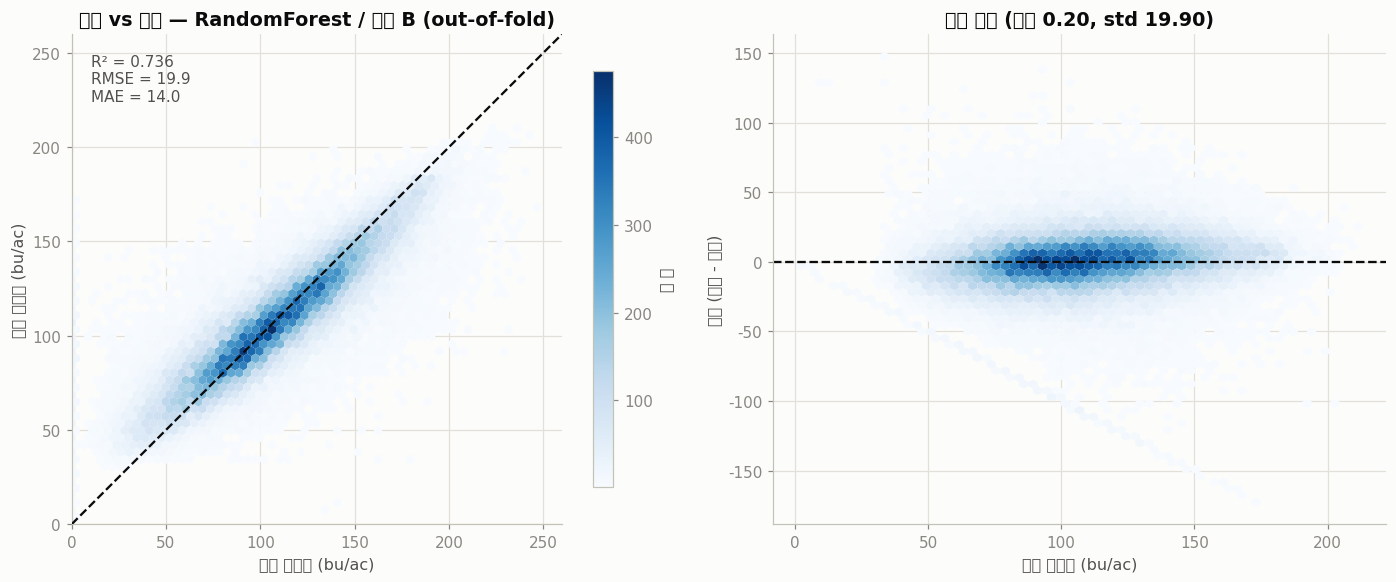

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.4))
lim = (0, 260)

ax = axes[0]; ax.set_axisbelow(True)
hb = ax.hexbin(y, oof_best, gridsize=60, extent=(*lim, *lim), mincnt=1, cmap='Blues', linewidths=0)
ax.plot(lim, lim, color=INK, linestyle='--', linewidth=1.5, zorder=3)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('실측 수확량 (bu/ac)'); ax.set_ylabel('예측 수확량 (bu/ac)')
ax.set_title('예측 vs 실측 — %s / 전략 %s (out-of-fold)' % (BEST_NAME, BEST_STRAT))
cb = fig.colorbar(hb, ax=ax, shrink=0.85); cb.set_label('행 수', color=SECOND); cb.outline.set_edgecolor(AXIS)
ax.annotate('R² = %.3f\nRMSE = %.1f\nMAE = %.1f' % (r2_score(y, oof_best), rmse(y, oof_best),
                                                     mean_absolute_error(y, oof_best)),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top', fontsize=10, color=SECOND)

ax = axes[1]; ax.set_axisbelow(True)
resid = y - oof_best
ax.hexbin(oof_best, resid, gridsize=60, mincnt=1, cmap='Blues', linewidths=0)
ax.axhline(0, color=INK, linestyle='--', linewidth=1.5)
ax.set_xlabel('예측 수확량 (bu/ac)'); ax.set_ylabel('잔차 (실측 - 예측)')
ax.set_title('잔차 분포 (평균 %.2f, std %.2f)' % (resid.mean(), resid.std()))
fig.tight_layout()
save(fig, 'fig14_pred_vs_actual.png'); plt.show()

## 4. 온도 반응곡선 (핵심 시각화)

`GDD_above_29`는 **전략 A에만 명시적 피처로 존재**한다(전략 B는 86개 1℃ 구간). 따라서 반응곡선은
**전략 A의 최고 트리모델**로 그린다.

두 가지 곡선을 그린다.
- **(왼쪽) 표준 PDP**: `GDD_above_29`만 바꾸고 나머지는 고정. sklearn `partial_dependence`.
  단, 총 노출일수 184 제약을 무시하므로 물리적으로는 불가능한 조합을 포함한다.
- **(오른쪽) 제약 반응곡선**: 하루를 `below29`에서 `above29`로 **옮긴다**(합 보존).
  02·03에서 확인한 **대체효과**와 같은 실험이며, 온난화의 실제 의미에 가깝다.

In [12]:
TREES = [m for m in ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'GradientBoosting'] if m in FACTORIES]
resA = res[(res.strategy == 'A') & (res.model.isin(TREES))].sort_values('r2_mean', ascending=False)
PDP_NAME = resA.iloc[0]['model']
print('전략 A 최고 트리모델: %s (R² %.4f)' % (PDP_NAME, resA.iloc[0]['r2_mean']))

pdp_model = FACTORIES[PDP_NAME]()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    pdp_model.fit(XA, y)

rng = np.random.default_rng(0)
samp = rng.choice(len(XA), size=6000, replace=False)
Xs = XA.iloc[samp].copy()

# (1) 표준 PDP
pd_res = partial_dependence(pdp_model, Xs, features=['GDD_above_29'], grid_resolution=40, kind='average')
gx = pd_res['grid_values'][0]; gy = pd_res['average'][0]

# (2) 제약 반응곡선: above29 = v 로 두고, 잃은/얻은 일수를 below29 에서 상계 (합 보존)
orig_a = Xs['GDD_above_29'].to_numpy().copy()
orig_b = Xs['GDD_below_29'].to_numpy().copy()
lo_b, hi_b = np.quantile(XA['GDD_below_29'], [0.001, 0.999])
vs = np.linspace(0, 70, 36)
curve, nvalid = [], []
for v in vs:
    X2 = Xs.copy()
    new_b = orig_b + (orig_a - v)
    ok = (new_b >= lo_b) & (new_b <= hi_b)
    X2['GDD_above_29'] = v
    X2['GDD_below_29'] = new_b
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p = pdp_model.predict(X2[ok])
    curve.append(p.mean()); nvalid.append(int(ok.sum()))
curve = np.array(curve); nvalid = np.array(nvalid)
keep = nvalid >= 300
print('제약 곡선: 유효 표본 >=300 인 격자 %d/%d' % (keep.sum(), len(vs)))
print('제약 곡선 정점: above29=%.0f 일 (%.1f bu/ac) -> 최저 %.1f bu/ac @ %.0f 일'
      % (vs[keep][curve[keep].argmax()], curve[keep].max(),
         curve[keep].min(), vs[keep][curve[keep].argmin()]))

전략 A 최고 트리모델: LightGBM (R² 0.6937)
제약 곡선: 유효 표본 >=300 인 격자 36/36
제약 곡선 정점: above29=10 일 (118.9 bu/ac) -> 최저 74.0 bu/ac @ 70 일


saved: ../outputs/figures/fig15_temperature_response.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/2971083421.py:21: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/2971083421.py:21: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/2971083421.py:21: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/2971083421.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/2971083421.py:21: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_

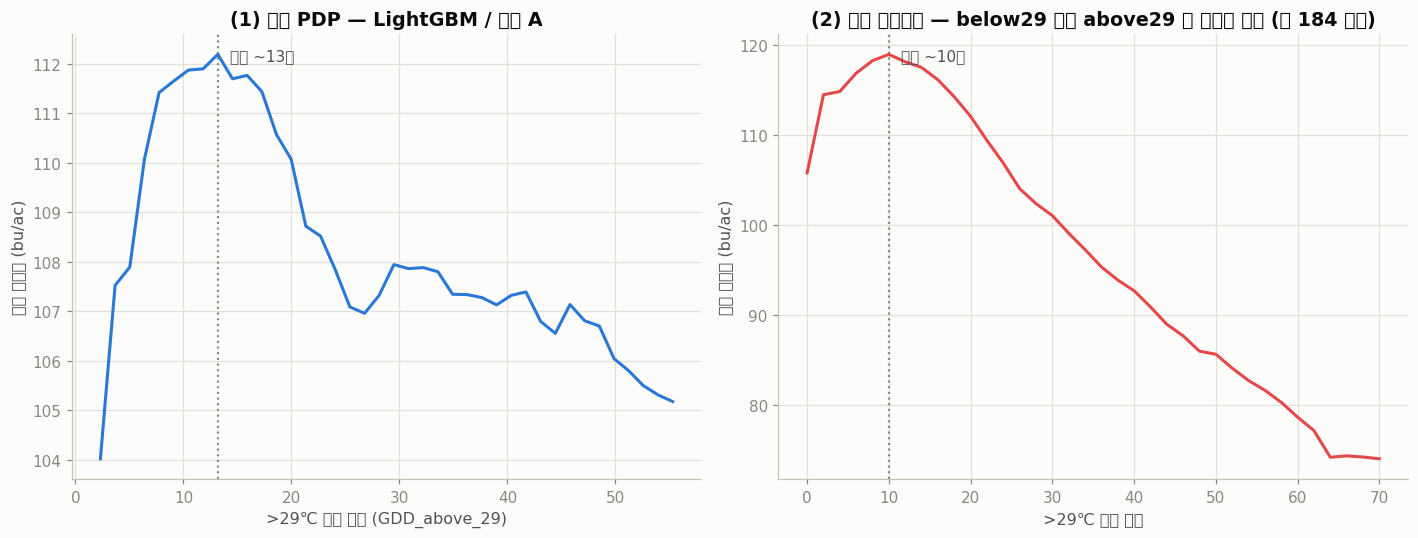

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

ax = axes[0]; ax.set_axisbelow(True)
ax.plot(gx, gy, color=BLUE, zorder=3)
pk = int(np.argmax(gy))
ax.axvline(gx[pk], color=MUTED, linestyle=':', linewidth=1.4, zorder=2)
ax.annotate('정점 ~%.0f일' % gx[pk], xy=(gx[pk], gy[pk]), xytext=(8, -4),
            textcoords='offset points', color=SECOND, fontsize=10)
ax.set_title('(1) 표준 PDP — %s / 전략 A' % PDP_NAME)
ax.set_xlabel('>29℃ 노출 일수 (GDD_above_29)'); ax.set_ylabel('예측 수확량 (bu/ac)')

ax = axes[1]; ax.set_axisbelow(True)
ax.plot(vs[keep], curve[keep], color=RED, zorder=3)
pk2 = int(curve[keep].argmax())
ax.axvline(vs[keep][pk2], color=MUTED, linestyle=':', linewidth=1.4, zorder=2)
ax.annotate('정점 ~%.0f일' % vs[keep][pk2], xy=(vs[keep][pk2], curve[keep][pk2]), xytext=(8, -4),
            textcoords='offset points', color=SECOND, fontsize=10)
ax.set_title('(2) 제약 반응곡선 — below29 에서 above29 로 하루씩 이동 (합 184 보존)')
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('예측 수확량 (bu/ac)')

fig.tight_layout()
save(fig, 'fig15_temperature_response.png'); plt.show()

**해석 — 29℃ 꺾임이 모델에서 재현된다.**

- **제약 반응곡선**(오른쪽)은 하루를 `below29`에서 `above29`로 옮긴 것으로, 정점이 **~10일**이고
  거기서부터 70일까지 **118.9 → 74.0 bu/ac (−45)** 로 단조 감소한다.
  이는 02의 비모수 구간평균이 보여준 **정점 ~10일 / 최저 68 bu/ac** 와 거의 일치한다.
  **모델이 데이터를 외운 게 아니라 임계 구조를 학습했다는 증거**다.
- **표준 PDP**(왼쪽)는 정점이 ~13일로 약간 오른쪽인데, `below29`를 고정한 채 `above29`만 늘리므로
  총 노출일수가 184를 넘는 **물리적으로 불가능한 조합**을 포함하기 때문이다.
  총합 제약을 지키는 오른쪽 곡선이 해석상 옳다.
- 두 곡선 모두 노출이 0에 가까울 때도 수확량이 낮은 **역U자**를 보인다(냉량지역은 고온 부족).

## 5. 갈래 2 — 해석용 모델 (카운티 · 연도 고정효과)

예측 모델에서 1위였던 `spH` 같은 변수는 **"옥수수가 잘 되는 지역"의 대리변수**다. 온도의 순수
기여를 보려면 지역과 연도를 통제해야 한다.

**2-way within 변환**(카운티 평균 + 연도 평균 제거)을 교대 사영(alternating projections)으로 수행한다.
패널이 불균형이라 단순 이중 차감은 정확하지 않으므로 수렴할 때까지 반복한다.

- soil 변수들은 **시간불변** → 카운티 고정효과에 흡수되어 자동 탈락한다.
- 남는 설명변수: `GDD_below_T`, `GDD_above_T`, `ppt`, `ppt_sq`
- 표준오차는 **카운티 클러스터 로버스트**로 계산한다.
- 관심 대상: **대체효과 `b_above − b_below`** (온화한 하루를 더운 하루로 바꿀 때의 효과)

In [14]:
ci = pd.factorize(A['stco'])[0]
ti = pd.factorize(A['year'])[0]
nc, nt = ci.max() + 1, ti.max() + 1
cnt_c = np.bincount(ci, minlength=nc).astype(float)
cnt_t = np.bincount(ti, minlength=nt).astype(float)

def demean2(v, iters=500, tol=1e-10):
    v = np.asarray(v, dtype=float).copy()
    for _ in range(iters):
        prev = v.copy()
        v -= (np.bincount(ci, v, minlength=nc) / cnt_c)[ci]
        v -= (np.bincount(ti, v, minlength=nt) / cnt_t)[ti]
        if np.max(np.abs(v - prev)) < tol:
            break
    return v

def within_ols(cols, T):
    Xr = np.column_stack([A[c].to_numpy(float) for c in cols])
    yt = demean2(y)
    Xt = np.column_stack([demean2(Xr[:, j]) for j in range(Xr.shape[1])])
    beta, *_ = np.linalg.lstsq(Xt, yt, rcond=None)
    u = yt - Xt @ beta
    XtX_inv = np.linalg.inv(Xt.T @ Xt)
    # 카운티 클러스터 로버스트 분산
    meat = np.zeros((len(cols), len(cols)))
    order = np.argsort(ci)
    Xs_, us_, cs_ = Xt[order], u[order], ci[order]
    bounds = np.searchsorted(cs_, np.arange(nc + 1))
    for gI in range(nc):
        a, b = bounds[gI], bounds[gI + 1]
        if b > a:
            s = Xs_[a:b].T @ us_[a:b]
            meat += np.outer(s, s)
    N, K = len(y), len(cols)
    K_eff = K + nc + nt - 1
    adj = (nc / (nc - 1)) * ((N - 1) / (N - K_eff))
    V = XtX_inv @ meat @ XtX_inv * adj
    se = np.sqrt(np.diag(V))
    within_r2 = 1 - (u ** 2).sum() / (yt ** 2).sum()
    c = np.zeros(K); c[cols.index('GDD_above_%d' % T)] = 1.0; c[cols.index('GDD_below_%d' % T)] = -1.0
    subst = float(c @ beta); subst_se = float(np.sqrt(c @ V @ c))
    return beta, se, within_r2, subst, subst_se

rows = []
for T in spec['strategy_A']['thresholds_available']:
    cols = ['GDD_below_%d' % T, 'GDD_above_%d' % T, 'ppt', 'ppt_sq']
    beta, se, wr2, subst, subst_se = within_ols(cols, T)
    rows.append({'T': T, 'b_below': beta[0], 'se_below': se[0], 'b_above': beta[1], 'se_above': se[1],
                 'subst': subst, 'subst_se': subst_se, 'subst_t': subst / subst_se, 'within_R2': wr2})

fe = pd.DataFrame(rows)
fe.to_csv(RES / 'fixed_effects_coefficients.csv', index=False)
print('카운티 %d개 + 연도 %d개 고정효과 흡수 후 (클러스터 SE: 카운티)' % (nc, nt))
print()
print(fe.round(4).to_string(index=False))
print('\n저장:', RES / 'fixed_effects_coefficients.csv')

fT = fe[fe['T'] == CANON].iloc[0]
print('\n--- T=%d 요약 ---' % CANON)
print('  b_below = %+.4f (SE %.4f)' % (fT.b_below, fT.se_below))
print('  b_above = %+.4f (SE %.4f)' % (fT.b_above, fT.se_above))
print('  대체효과 b_above - b_below = %+.4f (SE %.4f, t = %.1f)' % (fT.subst, fT.subst_se, fT.subst_t))
print('  within R² = %.4f' % fT.within_R2)

카운티 2644개 + 연도 35개 고정효과 흡수 후 (클러스터 SE: 카운티)

 T  b_below  se_below  b_above  se_above   subst  subst_se  subst_t  within_R2
28   0.1820    0.0322  -1.2890    0.0445 -1.4711    0.0256 -57.4321     0.1340
29   0.1369    0.0321  -1.5356    0.0455 -1.6725    0.0275 -60.7117     0.1532
30   0.0946    0.0323  -1.7193    0.0473 -1.8138    0.0300 -60.3727     0.1612
31   0.0665    0.0329  -1.8345    0.0497 -1.9010    0.0332 -57.1985     0.1579

저장: ../outputs/results/fixed_effects_coefficients.csv

--- T=29 요약 ---
  b_below = +0.1369 (SE 0.0321)
  b_above = -1.5356 (SE 0.0455)
  대체효과 b_above - b_below = -1.6725 (SE 0.0275, t = -60.7)
  within R² = 0.1532


### 5-1. 검증 — within 변환이 더미변수 회귀와 일치하는가

`demean2`(교대 사영)로 얻은 계수가 **카운티·연도 더미를 명시적으로 넣은 회귀**와 같은지 확인한다.
희소 더미 행렬 + `lsmr` 로 푼다.

> 반드시 **연속변수를 표준화**한 뒤 풀어야 한다. `ppt_sq`의 스케일이 ~4e5 라 표준화 없이는
> 반복해법이 수렴하지 못하고 엉뚱한 계수를 준다 (실제로 그렇게 확인했다).

In [15]:
from scipy import sparse
from scipy.sparse.linalg import lsmr

cols29 = ['GDD_below_%d' % CANON, 'GDD_above_%d' % CANON, 'ppt', 'ppt_sq']
Xc = A[cols29].to_numpy(float)
sd_c = Xc.std(0)
Xs_ = (Xc - Xc.mean(0)) / sd_c                     # 표준화: 조건수 개선 (필수)

n = len(y)
Dc = sparse.csr_matrix((np.ones(n), (np.arange(n), ci)), shape=(n, nc))
Dt = sparse.csr_matrix((np.ones(n), (np.arange(n), ti)), shape=(n, nt))[:, 1:]
Xsp = sparse.hstack([sparse.csr_matrix(Xs_), Dc, Dt]).tocsr()
sol = lsmr(Xsp, y, atol=1e-12, btol=1e-12, maxiter=100000)
b_dummy = sol[0][:4] / sd_c                        # 원 스케일로 환원

b_within = within_ols(cols29, CANON)[0]
print('%-14s %14s %14s' % ('', 'within 변환', '더미 회귀(lsmr)'))
for j, c in enumerate(cols29):
    print('%-14s %+14.4f %+14.4f' % (c, b_within[j], b_dummy[j]))
sub_d = b_dummy[1] - b_dummy[0]
print('%-14s %+14.4f %+14.4f' % ('대체효과', fT.subst, sub_d))
assert abs(fT.subst - sub_d) < 1e-3, '두 방법이 불일치'
print('\n두 방법 일치 (오차 %.2e) -> within 변환 결과 검증 완료' % abs(fT.subst - sub_d))
print('demean2 수렴: 카운티/연도 잔차 평균 max |.| = %.2e / %.2e'
      % (np.abs(np.bincount(ci, demean2(y), minlength=nc) / cnt_c).max(),
         np.abs(np.bincount(ti, demean2(y), minlength=nt) / cnt_t).max()))

                    within 변환    더미 회귀(lsmr)
GDD_below_29          +0.1369        +0.1369
GDD_above_29          -1.5356        -1.5356
ppt                   +0.0455        +0.0455
ppt_sq                -0.0000        -0.0000
대체효과                  -1.6725        -1.6725

두 방법 일치 (오차 1.02e-09) -> within 변환 결과 검증 완료
demean2 수렴: 카운티/연도 잔차 평균 max |.| = 1.14e-12 / 1.07e-14


saved: ../outputs/figures/fig16_fixed_effects.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/27335278.py:28: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/27335278.py:28: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/27335278.py:28: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/27335278.py:28: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38580/27335278.py:28: UserWarning: Glyph 45257 (\N{HANGUL SYLLABLE NAENG}) missing from font(s) DejaVu Sans.
  f

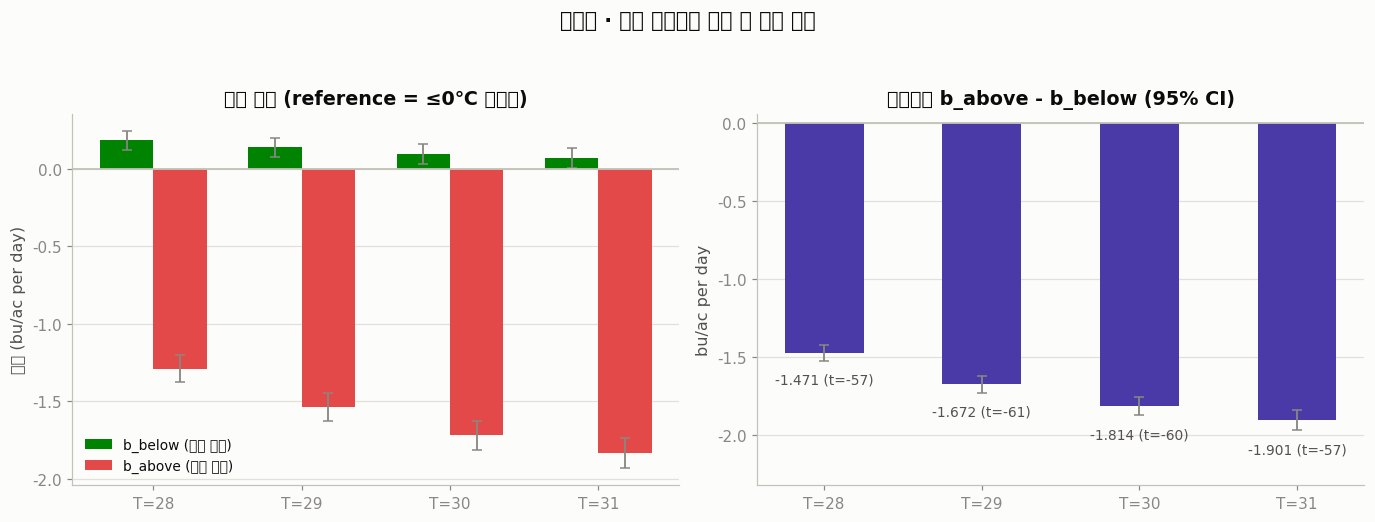

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

ax = axes[0]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
xp = np.arange(len(fe)); w = 0.36
ax.bar(xp - w/2, fe.b_below, width=w, yerr=1.96 * fe.se_below, color=GREEN,
       error_kw=dict(ecolor=MUTED, elinewidth=1.2, capsize=3), label='b_below (유익 노출)')
ax.bar(xp + w/2, fe.b_above, width=w, yerr=1.96 * fe.se_above, color=RED,
       error_kw=dict(ecolor=MUTED, elinewidth=1.2, capsize=3), label='b_above (고온 노출)')
ax.axhline(0, color=AXIS, linewidth=1.2)
ax.set_xticks(xp); ax.set_xticklabels(['T=%d' % t for t in fe['T']])
ax.set_ylabel('계수 (bu/ac per day)'); ax.set_title('개별 계수 (reference = ≤0℃ 냉량일)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
ax.bar(xp, fe.subst, width=0.5, yerr=1.96 * fe.subst_se, color=VIOLET,
       error_kw=dict(ecolor=MUTED, elinewidth=1.2, capsize=3))
ax.axhline(0, color=AXIS, linewidth=1.2)
# 라벨은 CI 아래끝(캡)보다 더 아래에 둔다 — 캡이 글자를 관통하지 않도록
for i, (v, se_, t_) in enumerate(zip(fe.subst, fe.subst_se, fe.subst_t)):
    ax.annotate('%.3f (t=%.0f)' % (v, t_), xy=(i, v - 1.96 * se_), xytext=(0, -8),
                textcoords='offset points', ha='center', va='top', fontsize=9, color=SECOND)
ax.set_ylim(min(fe.subst - 1.96 * fe.subst_se) * 1.18, 0.06)
ax.set_xticks(xp); ax.set_xticklabels(['T=%d' % t for t in fe['T']])
ax.set_ylabel('bu/ac per day')
ax.set_title('대체효과 b_above - b_below (95% CI)')

fig.suptitle('카운티 · 연도 고정효과 통제 후 온도 효과', fontsize=13.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, 'fig16_fixed_effects.png'); plt.show()

**해석 — 지역·연도를 모두 통제해도 더위 효과는 살아남고, 오히려 훨씬 커진다.**

카운티 고정효과가 `spH` 같은 "좋은 지역" 대리변수를 전부 흡수하고, 연도 고정효과가 기술추세와
전국적 충격을 흡수한 뒤에도:

| | T=28 | T=29 | T=30 | T=31 |
|---|---|---|---|---|
| `b_below` | +0.182 | +0.137 | +0.095 | +0.067 |
| `b_above` | −1.289 | −1.536 | −1.719 | −1.835 |
| **대체효과** | **−1.471** | **−1.673** | **−1.814** | **−1.901** |
| t 값 | −57.4 | −60.7 | −60.4 | −57.2 |

- **T=29에서 대체효과 = −1.67 bu/ac/day (SE 0.028, t = −60.7)**. 카운티 클러스터 로버스트 표준오차
  기준으로 압도적으로 유의하다. **온화한 하루를 29℃ 초과의 하루로 바꾸면 약 1.7 bu/ac를 잃는다.**
- 여기서는 `b_above` 자체도 **음수**다(−1.54). 03의 횡단면 회귀에서 `b_above`가 양수로 나왔던 것은
  지역 차이(더운 지역일수록 다른 토양·관행)가 섞였기 때문이며, 카운티 고정효과가 그걸 제거하자
  부호가 정상화됐다. 제약 4의 경고가 왜 필요했는지 보여준다.
- 03의 횡단면 대체효과(−0.71)보다 **2.4배 크다**. 카운티 내 연도 간 날씨 변동으로 식별하면
  효과가 더 크게 잡힌다 — 횡단면에는 적응(품종 선택, 관개 등)이 섞여 효과가 희석되기 때문이다.
- `within R² = 0.153`. 낮아 보이지만 이는 **고정효과가 설명한 몫을 뺀 나머지**에서 날씨만으로 설명한
  비율이므로, 예측 R²(0.73)와 직접 비교할 수 없다. 목적이 다른 모델이다.

## 6. 요약

In [17]:
print('=' * 70)
print('04 YIELD MODEL 요약')
print('=' * 70)
print('[갈래 1 · 예측용]  평가: GroupKFold(stco) %d-fold' % N_SPLITS)
print('  최종 승자: %s (전략 %s)' % (BEST_NAME, BEST_STRAT))
print('    R2   %.4f ± %.4f' % (best_row['r2_mean'], best_row['r2_std']))
print('    RMSE %.2f bu/ac | MAE %.2f bu/ac' % (best_row['rmse_mean'], best_row['mae_mean']))
print()
print('  모델군별 최고 R2:')
lin = res[res.model.isin(['OLS','Ridge','Lasso','ElasticNet'])].r2_mean.max()
skl = res[res.model.isin(['RandomForest','GradientBoosting'])].r2_mean.max()
mod = res[res.model.isin(['XGBoost','LightGBM','CatBoost'])].r2_mean
print('    선형          %.4f' % lin)
print('    sklearn 트리  %.4f' % skl)
if len(mod): print('    최신 부스팅   %.4f' % mod.max())
print('    부스팅 - 선형 = %+.4f' % ((mod.max() if len(mod) else skl) - lin))
print()
print('  전략 A vs B (같은 모델끼리 짝비교):')
print('    트리/부스팅 %d/%d 개에서 B 우세 (평균 dR2 %+.4f)'
      % (int((pair.loc[TREE,'B - A']>0).sum()), len(TREE), pair.loc[TREE,'B - A'].mean()))
print('    선형은 Lasso/EN만 B 우세; OLS/Ridge-B 는 공선성으로 붕괴 (fold별 R2 %s)'
      % res[(res.model=='OLS')&(res.strategy=='B')].r2_folds.iloc[0])
print('    -> 최고 성능은 전략 B (%s)' % BEST_STRAT)
print('  year 기여: dR2 %+.4f' % (best_row['r2_mean'] - row_noyear['r2_mean']))
print()
print('[갈래 2 · 해석용]  카운티 %d + 연도 %d 고정효과, 카운티 클러스터 SE' % (nc, nt))
print('  T=%d : b_below %+.4f  b_above %+.4f' % (CANON, fT.b_below, fT.b_above))
print('  대체효과 %+.4f bu/ac/day (SE %.4f, t=%.1f) -> %s'
      % (fT.subst, fT.subst_se, fT.subst_t,
         '고온 효과 생존 (유의하게 음수)' if fT.subst + 1.96*fT.subst_se < 0 else '유의하지 않음'))
print('  within R2 %.4f' % fT.within_R2)
print()
print('[온도 반응곡선]')
print('  표준 PDP 정점    : above29 = %.0f 일' % gx[pk])
print('  제약 반응곡선 정점: above29 = %.0f 일 (%.1f -> %.1f bu/ac)'
      % (vs[keep][pk2], curve[keep].max(), curve[keep].min()))
print()
print('[저장]')
print('  data/processed/yield_model_final.joblib   (05,06 에서 y_hat 생성)')
print('  data/processed/oof_predictions.parquet')
print('  outputs/results/model_comparison.csv')
print('  outputs/results/lasso_elasticnet_selected.csv')
print('  outputs/results/fixed_effects_coefficients.csv')
print()
print('[설치 실패 모델]', MISSING if MISSING else '없음 (XGB/LGBM/CatBoost 모두 사용)')

04 YIELD MODEL 요약
[갈래 1 · 예측용]  평가: GroupKFold(stco) 5-fold
  최종 승자: RandomForest (전략 B)
    R2   0.7362 ± 0.0082
    RMSE 19.90 bu/ac | MAE 13.98 bu/ac

  모델군별 최고 R2:
    선형          0.4377
    sklearn 트리  0.7362
    최신 부스팅   0.7327
    부스팅 - 선형 = +0.2950

  전략 A vs B (같은 모델끼리 짝비교):
    트리/부스팅 5/5 개에서 B 우세 (평균 dR2 +0.0368)
    선형은 Lasso/EN만 B 우세; OLS/Ridge-B 는 공선성으로 붕괴 (fold별 R2 0.413|0.476|0.440|-1.198|0.427)
    -> 최고 성능은 전략 B (B)
  year 기여: dR2 +0.0971

[갈래 2 · 해석용]  카운티 2644 + 연도 35 고정효과, 카운티 클러스터 SE
  T=29 : b_below +0.1369  b_above -1.5356
  대체효과 -1.6725 bu/ac/day (SE 0.0275, t=-60.7) -> 고온 효과 생존 (유의하게 음수)
  within R2 0.1532

[온도 반응곡선]
  표준 PDP 정점    : above29 = 13 일
  제약 반응곡선 정점: above29 = 10 일 (118.9 -> 74.0 bu/ac)

[저장]
  data/processed/yield_model_final.joblib   (05,06 에서 y_hat 생성)
  data/processed/oof_predictions.parquet
  outputs/results/model_comparison.csv
  outputs/results/lasso_elasticnet_selected.csv
  outputs/results/fixed_effects_coefficients.csv

[설치 실패 모델] 없음 (XGB